In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

TASK 1 : DATASET EXPLORATION

Dataset Summary
----------------------------------------
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)

Image Shape     : (28, 28)
Number of Classes : 10


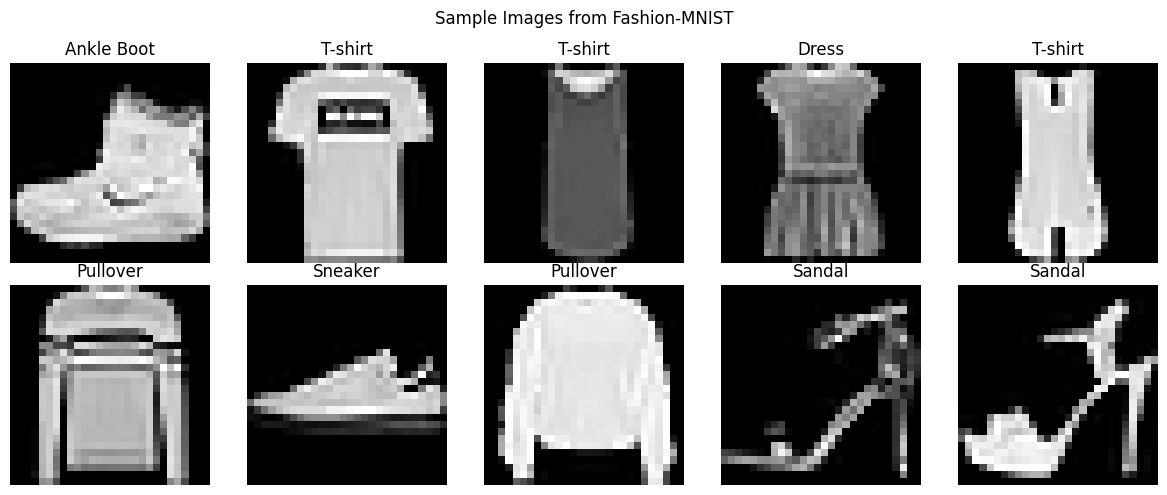

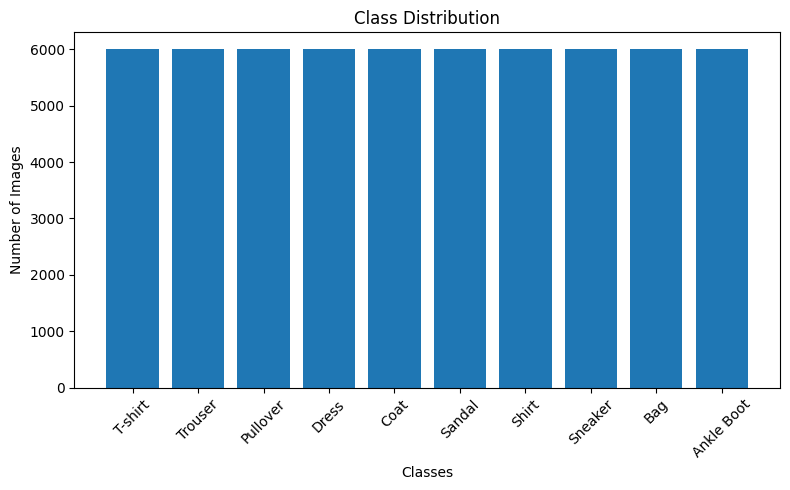


Task 1 Completed Successfully.


In [ ]:
# ============================================================
# TASK 1: DATASET EXPLORATION
# ============================================================

print("=" * 70)
print("TASK 1 : DATASET EXPLORATION")
print("=" * 70)

# Load Fashion-MNIST Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Dataset Information
print("\nDataset Summary")
print("-" * 40)

print(f"Training Images : {X_train.shape}")
print(f"Training Labels : {y_train.shape}")

print(f"Testing Images  : {X_test.shape}")
print(f"Testing Labels  : {y_test.shape}")

print(f"\nImage Shape     : {X_train[0].shape}")
print(f"Number of Classes : {len(np.unique(y_train))}")

# Class Names
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Display 10 Sample Images
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Sample Images from Fashion-MNIST")
plt.tight_layout()

plt.savefig("Sample_Images.pdf")
plt.savefig("Sample_Images.eps", format='eps', dpi=600)

plt.show()

# Class Distribution
plt.figure(figsize=(8,5))

classes, counts = np.unique(y_train, return_counts=True)

plt.bar(class_names, counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("Class_Distribution.pdf")
plt.savefig("Class_Distribution.eps", format='eps', dpi=600)

plt.show()

print("\nTask 1 Completed Successfully.")

In [ ]:
# ============================================================
# TASK 2 : DATA PREPROCESSING
# ============================================================

print("\n")
print("=" * 70)
print("TASK 2 : DATA PREPROCESSING")
print("=" * 70)

# Shapes Before Preprocessing
print("\nBefore Preprocessing")
print("-" * 40)

print(f"Training Image Shape : {X_train.shape}")
print(f"Testing Image Shape  : {X_test.shape}")

print(f"Training Label Shape : {y_train.shape}")
print(f"Testing Label Shape  : {y_test.shape}")

# ------------------------------------------------------------
# Flatten Images
# ------------------------------------------------------------

X_train_flat = X_train.reshape(X_train.shape[0], 28*28)
X_test_flat = X_test.reshape(X_test.shape[0], 28*28)

# ------------------------------------------------------------
# Normalize Pixel Values
# ------------------------------------------------------------

X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

# ------------------------------------------------------------
# One-Hot Encode Labels
# ------------------------------------------------------------

y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

# Shapes After Preprocessing
print("\nAfter Preprocessing")
print("-" * 40)

print(f"Training Image Shape : {X_train_flat.shape}")
print(f"Testing Image Shape  : {X_test_flat.shape}")

print(f"Training Label Shape : {y_train_encoded.shape}")
print(f"Testing Label Shape  : {y_test_encoded.shape}")

# Display Sample Information
print("\nSample Image")

print("-" * 40)

print("Original Image Shape :", X_train[0].shape)
print("Flattened Shape      :", X_train_flat[0].shape)

print("\nFirst 20 Pixel Values (Normalized):")

print(X_train_flat[0][:20])

print("\nOne-Hot Encoded Label")

print(y_train_encoded[0])

print("\nTask 2 Completed Successfully.")



TASK 2 : DATA PREPROCESSING

Before Preprocessing
----------------------------------------
Training Image Shape : (60000, 28, 28)
Testing Image Shape  : (10000, 28, 28)
Training Label Shape : (60000,)
Testing Label Shape  : (10000,)

After Preprocessing
----------------------------------------
Training Image Shape : (60000, 784)
Testing Image Shape  : (10000, 784)
Training Label Shape : (60000, 10)
Testing Label Shape  : (10000, 10)

Sample Image
----------------------------------------
Original Image Shape : (28, 28)
Flattened Shape      : (784,)

First 20 Pixel Values (Normalized):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

One-Hot Encoded Label
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

Task 2 Completed Successfully.


In [ ]:
# ============================================================
# TASK 3 : MODEL CONSTRUCTION
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("\n")
print("=" * 70)
print("TASK 3 : MODEL CONSTRUCTION")
print("=" * 70)

# Build the Multi-Layer Perceptron (MLP)
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name="Hidden_Layer_1"),
    Dense(64, activation='relu', name="Hidden_Layer_2"),
    Dense(10, activation='softmax', name="Output_Layer")
])

print("\nModel Summary")
print("-" * 70)

model.summary()

print("\nTask 3 Completed Successfully.")



TASK 3 : MODEL CONSTRUCTION

Model Summary
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Task 3 Completed Successfully.


In [ ]:
# ============================================================
# TASK 4 : MODEL TRAINING
# ============================================================

from tensorflow.keras.optimizers import Adam

print("\n")
print("=" * 70)
print("TASK 4 : MODEL TRAINING")
print("=" * 70)

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Compilation Completed")

print("\nTraining Started...")
print("-" * 70)

# Train the model
history = model.fit(
    X_train_flat,
    y_train_encoded,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

print("-" * 70)
print("Training Completed Successfully.")

# Final Training Metrics
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("\nFinal Training Results")
print("-" * 40)

print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")


print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")



TASK 4 : MODEL TRAINING

Model Compilation Completed

Training Started...
----------------------------------------------------------------------
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8172 - loss: 0.5155 - val_accuracy: 0.8504 - val_loss: 0.4149
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8625 - loss: 0.3778 - val_accuracy: 0.8640 - val_loss: 0.3668
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8768 - loss: 0.3386 - val_accuracy: 0.8616 - val_loss: 0.3851
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8836 - loss: 0.3153 - val_accuracy: 0.8762 - val_loss: 0.3414
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8898 - loss: 0.2952 - val_accuracy: 0.8729 - val_loss: 0.3555
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8948 - loss: 0.2822 - val_accuracy: 0.8819 - val_loss: 0.3325
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8992 

In [ ]:
# ============================================================
# TASK 5 : MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np

print("\n")
print("=" * 70)
print("TASK 5 : MODEL EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Evaluate on Test Dataset
# ------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    X_test_flat,
    y_test_encoded,
    verbose=0
)

print("\nTest Dataset Evaluation")
print("-" * 40)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# ------------------------------------------------------------
# Predict Classes
# ------------------------------------------------------------

y_pred_prob = model.predict(X_test_flat, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\nPerformance Metrics")
print("-" * 40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print("\nClassification Report")
print("-" * 70)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

# Save Report
with open("classification_report.txt", "w") as file:
    file.write(report)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix")
print("-" * 70)

print(cm)



TASK 5 : MODEL EVALUATION

Test Dataset Evaluation
----------------------------------------
Test Loss     : 0.3861
Test Accuracy : 0.8802

Performance Metrics
----------------------------------------
Accuracy  : 0.8802
Precision : 0.8824
Recall    : 0.8802
F1-Score  : 0.8789

Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

     T-shirt       0.81      0.87      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.85      0.71      0.78      1000
       Dress       0.85      0.89      0.87      1000
        Coat       0.72      0.88      0.79      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.78      0.64      0.70      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle Boot       0.97      0.94      0.95      1000

    accuracy                    

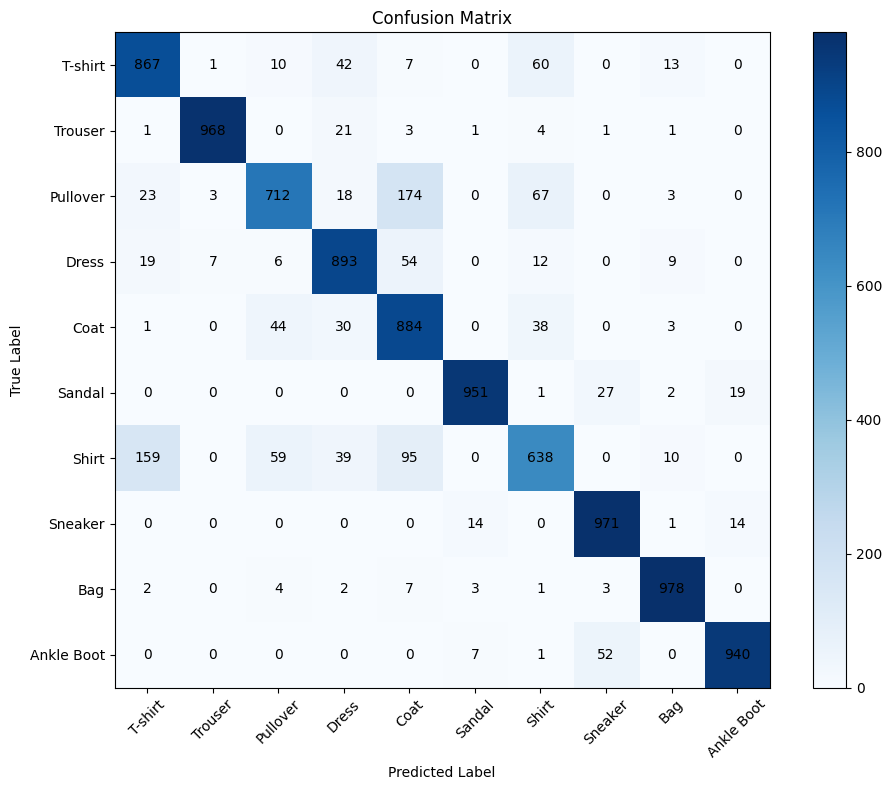

In [ ]:
# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Write values inside matrix

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("Confusion_Matrix.pdf")
plt.savefig("Confusion_Matrix.eps",
            format="eps",
            dpi=600)

plt.show()

In [ ]:
# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PERFORMANCE SUMMARY")
print("=" * 70)

print("{:<15} {:<10}".format("Metric","Value"))
print("-"*30)

print("{:<15} {:.4f}".format("Accuracy",accuracy))
print("{:<15} {:.4f}".format("Precision",precision))
print("{:<15} {:.4f}".format("Recall",recall))
print("{:<15} {:.4f}".format("F1-Score",f1))



PERFORMANCE SUMMARY
Metric          Value     
------------------------------
Accuracy        0.8802
Precision       0.8824
Recall          0.8802
F1-Score        0.8789


In [ ]:
!pip install -U scikeras
!pip install -U scikit-learn

In [ ]:
# ============================================================
# HYPERPARAMETER OPTIMIZATION USING RANDOMIZED SEARCH
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

import pandas as pd

print("\n")
print("=" * 70)
print("HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Model Building Function
# ------------------------------------------------------------

def create_model(hidden_layers=2,
                 neurons=128,
                 activation='relu',
                 optimizer='adam',
                 learning_rate=0.001,
                 dropout_rate=0.0):

    model = Sequential()

    # First Hidden Layer
    model.add(Dense(neurons,
                    activation=activation,
                    input_shape=(784,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Additional Hidden Layers
    for _ in range(hidden_layers - 1):

        model.add(Dense(neurons,
                        activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output Layer
    model.add(Dense(10,
                    activation='softmax'))

    # Optimizer Selection
    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)

    elif optimizer == "rmsprop":
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ------------------------------------------------------------
# Wrap Model
# ------------------------------------------------------------

classifier = KerasClassifier(
    model=create_model,
    verbose=0
)

# ------------------------------------------------------------
# Search Space
# ------------------------------------------------------------

param_dist = {

 "model__hidden_layers":[1,2],

   "model__neurons":[64,128],

    "model__activation": [
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__optimizer": [
        "adam",
        "sgd"

    ],

    "model__learning_rate": [
            0.01,
        0.001
    ],

    "model__dropout_rate": [
        0.0,
        0.2

    ],

    "batch_size": [
        16,
        32,
        64,
        128
    ],
"epochs": [5,10]
}

# ------------------------------------------------------------
# Randomized Search
# ------------------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=classifier,

    param_distributions=param_dist,

    n_iter=5,

    cv=3,

    scoring='accuracy',

    random_state=42,

    n_jobs=-1
)

print("\nSearching Best Hyperparameters...\n")

random_search.fit(
    X_train_flat,
    y_train_encoded
)

print("\nSearch Completed Successfully.")



HYPERPARAMETER OPTIMIZATION

Searching Best Hyperparameters...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Search Completed Successfully.


In [ ]:
# ============================================================
# BEST PARAMETERS
# ============================================================

print("\n")
print("=" * 70)
print("BEST HYPERPARAMETERS")
print("=" * 70)

print(f"Hidden Layers   : {random_search.best_params_['model__hidden_layers']}")
print(f"Hidden Neurons  : {random_search.best_params_['model__neurons']}")
print(f"Activation      : {random_search.best_params_['model__activation']}")
print(f"Optimizer       : {random_search.best_params_['model__optimizer']}")
print(f"Learning Rate   : {random_search.best_params_['model__learning_rate']}")
print(f"Dropout         : {random_search.best_params_['model__dropout_rate']}")
print(f"Batch Size      : {random_search.best_params_['batch_size']}")
print(f"Epochs          : {random_search.best_params_['epochs']}")

print(f"\nBest CV Accuracy : {random_search.best_score_:.4f}")



BEST HYPERPARAMETERS
Hidden Layers   : 1
Hidden Neurons  : 128
Activation      : relu
Optimizer       : adam
Learning Rate   : 0.001
Dropout         : 0.0
Batch Size      : 16
Epochs          : 10

Best CV Accuracy : 0.8781


In [ ]:
with open("best_parameters.txt","w") as file:

    file.write("BEST HYPERPARAMETERS\n")
    file.write("="*40 + "\n\n")

    for key,value in random_search.best_params_.items():
        file.write(f"{key} : {value}\n")

    file.write("\n")

    file.write(f"Cross Validation Accuracy : {random_search.best_score_:.4f}")

In [ ]:
# ============================================================
# RETRAIN USING BEST PARAMETERS
# ============================================================

best_model = random_search.best_estimator_

best_model.fit(
    X_train_flat,
    y_train_encoded,
    verbose=1
)

test_accuracy = best_model.score(
    X_test_flat,
    y_test_encoded
)

print("\nOptimized Test Accuracy")

print(f"{test_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.8285 - loss: 0.4832
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8690 - loss: 0.3648
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8797 - loss: 0.3284
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8862 - loss: 0.3084
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8923 - loss: 0.2921
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8962 - loss: 0.2785
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9004 - loss: 0.2657
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9043 - loss: 0.2565
Epoch 9/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9060 - loss: 0.2475
Epoch 10/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9104 - loss: 0.2396

Optimized Test Accuracy
0.8809


In [ ]:
results = pd.DataFrame(random_search.cv_results_)

results = results[[
    "mean_test_score",
    "rank_test_score",
    "param_model__hidden_layers",
    "param_model__neurons",
    "param_model__activation",
    "param_model__optimizer",
    "param_model__learning_rate",
    "param_batch_size",
    "param_epochs"
]]

results = results.sort_values(
    by="rank_test_score"
)

print(results.head(10))

results.to_csv(
    "hyperparameter_results.csv",
    index=False
)

   mean_test_score  rank_test_score  param_model__hidden_layers  \
0         0.878100                1                           1   
2         0.875350                2                           2   
3         0.847433                3                           2   
1         0.830083                4                           1   
4         0.730283                5                           1   

   param_model__neurons param_model__activation param_model__optimizer  \
0                   128                    relu                   adam   
2                   128                 sigmoid                   adam   
3                   128                    relu                   adam   
1                   128                    tanh                    sgd   
4                   128                 sigmoid                    sgd   

   param_model__learning_rate  param_batch_size  param_epochs  
0                       0.001                16            10  
2                       

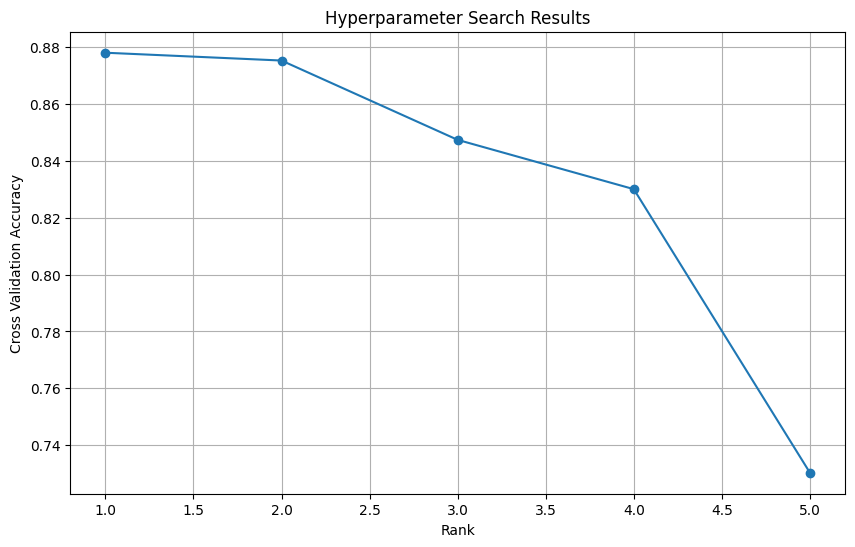

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    results["rank_test_score"],
    results["mean_test_score"],
    marker='o'
)

plt.xlabel("Rank")

plt.ylabel("Cross Validation Accuracy")

plt.title("Hyperparameter Search Results")

plt.grid(True)

plt.savefig("Hyperparameter_Search.pdf")

plt.savefig(
    "Hyperparameter_Search.eps",
    dpi=600,
    format='eps'
)

plt.show()

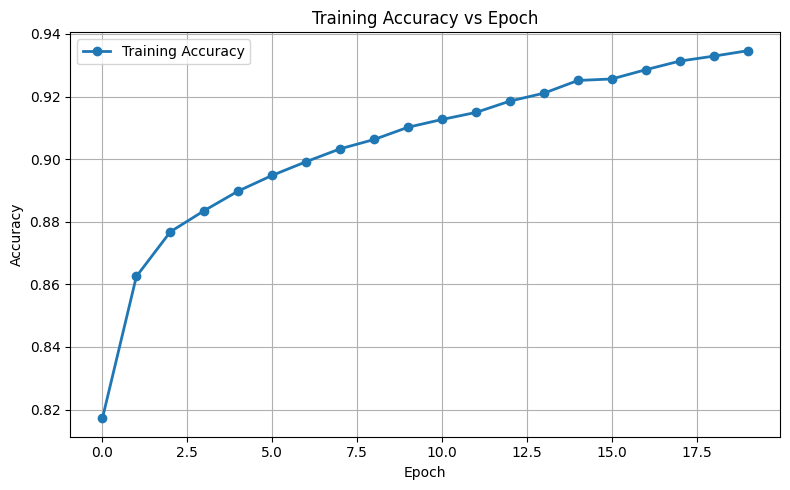

In [ ]:
# ============================================================
# TRAINING ACCURACY VS EPOCH
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.title("Training Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("Training_Accuracy.pdf")

plt.savefig(
    "Training_Accuracy.eps",
    dpi=600,
    format="eps"
)

plt.show()

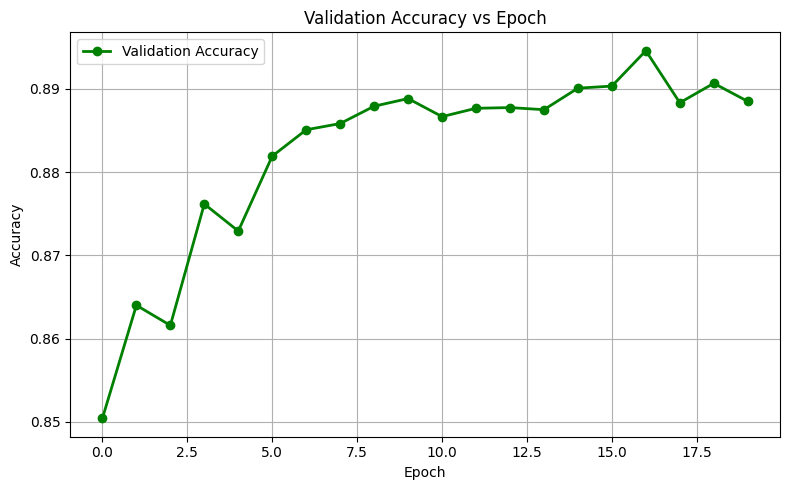

In [ ]:
# ============================================================
# VALIDATION ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['val_accuracy'],
    marker='o',
    color='green',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Validation Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("Validation_Accuracy.pdf")

plt.savefig(
    "Validation_Accuracy.eps",
    dpi=600,
    format="eps"
)

plt.show()

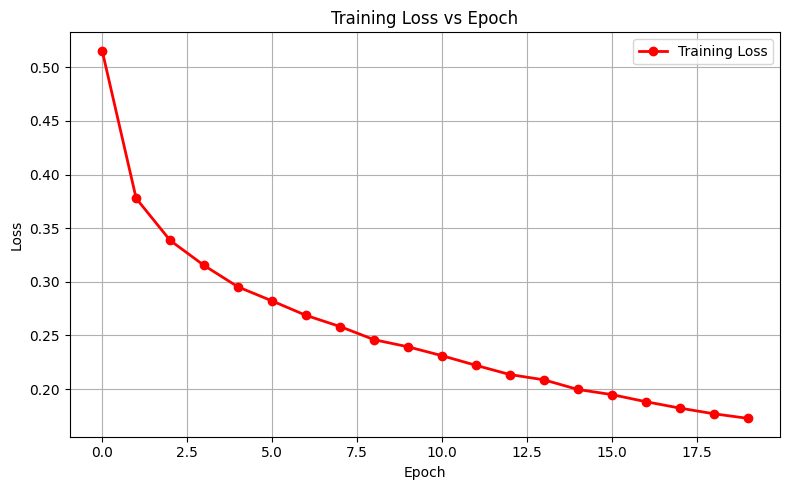

In [ ]:
# ============================================================
# TRAINING LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o',
    color='red',
    linewidth=2,
    label='Training Loss'
)

plt.title("Training Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("Training_Loss.pdf")

plt.savefig(
    "Training_Loss.eps",
    dpi=600,
    format="eps"
)

plt.show()

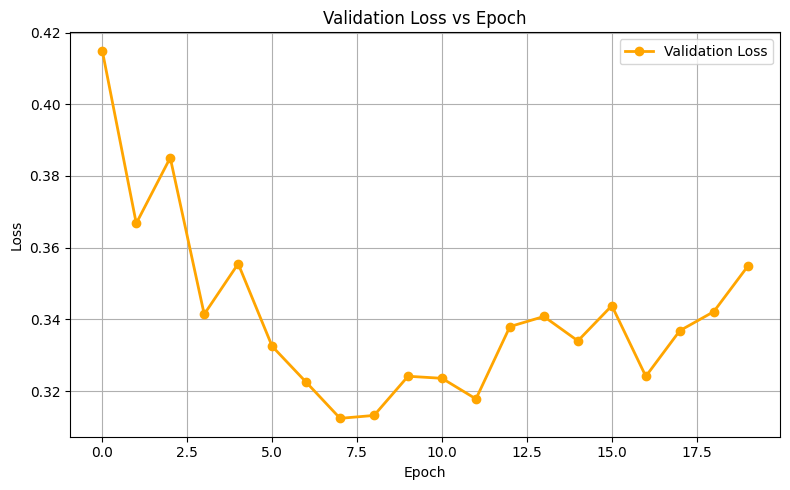

In [ ]:
# ============================================================
# VALIDATION LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['val_loss'],
    marker='o',
    color='orange',
    linewidth=2,
    label='Validation Loss'
)

plt.title("Validation Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("Validation_Loss.pdf")

plt.savefig(
    "Validation_Loss.eps",
    dpi=600,
    format="eps"
)

plt.show()

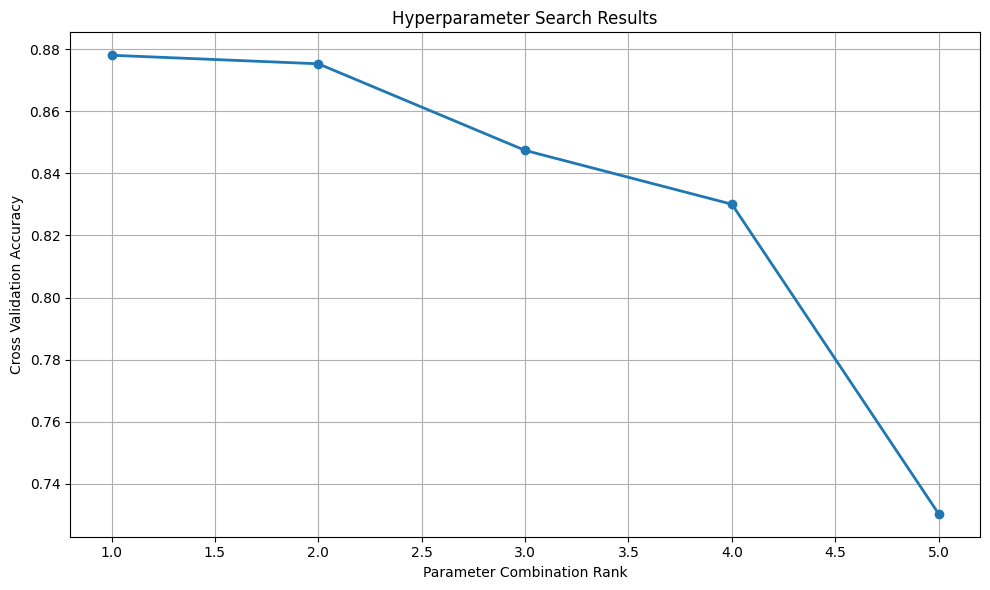

In [ ]:
# ============================================================
# HYPERPARAMETER SEARCH RESULTS
# ============================================================

import pandas as pd

results = pd.DataFrame(random_search.cv_results_)

results = results.sort_values(
    by="rank_test_score"
)

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(results)+1),
    results["mean_test_score"],
    marker='o',
    linewidth=2
)

plt.title("Hyperparameter Search Results")

plt.xlabel("Parameter Combination Rank")

plt.ylabel("Cross Validation Accuracy")

plt.grid(True)

plt.tight_layout()

plt.savefig("Hyperparameter_Search.pdf")

plt.savefig(
    "Hyperparameter_Search.eps",
    dpi=600,
    format='eps'
)

plt.show()

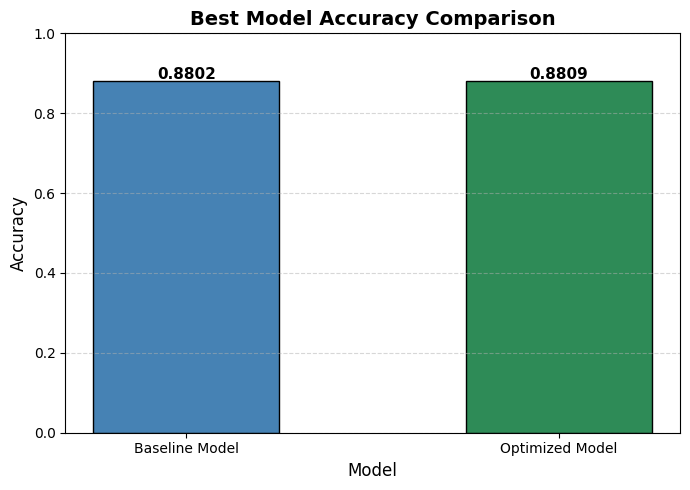

In [ ]:
# ============================================================
# BEST MODEL ACCURACY COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# Baseline and Optimized Accuracy
# Replace these values with your actual accuracies

baseline_accuracy = accuracy          # Accuracy from Task 5
optimized_accuracy = test_accuracy    # Accuracy after Hyperparameter Optimization

models = ["Baseline Model", "Optimized Model"]
accuracies = [baseline_accuracy, optimized_accuracy]

plt.figure(figsize=(7,5))

bars = plt.bar(
    models,
    accuracies,
    color=["steelblue", "seagreen"],
    edgecolor="black",
    width=0.5
)

# Add accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Best Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.ylim(0, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save Figures
plt.savefig("Best_Model_Accuracy_Comparison.pdf", dpi=600)
plt.savefig("Best_Model_Accuracy_Comparison.eps", format="eps", dpi=600)

plt.show()

In [ ]:
# ============================================================
# RESULTS : BEST HYPERPARAMETERS
# ============================================================

print("\n")
print("=" * 70)
print("RESULTS")
print("=" * 70)

print("\nBest Hyperparameters")
print("-" * 40)

print(f"Hidden Layers            : {random_search.best_params_['model__hidden_layers']}")
print(f"Hidden Neurons           : {random_search.best_params_['model__neurons']}")
print(f"Learning Rate            : {random_search.best_params_['model__learning_rate']}")
print(f"Batch Size               : {random_search.best_params_['batch_size']}")
print(f"Optimizer                : {random_search.best_params_['model__optimizer']}")
print(f"Activation Function      : {random_search.best_params_['model__activation']}")
print(f"Epochs                   : {random_search.best_params_['epochs']}")
print(f"Dropout                  : {random_search.best_params_['model__dropout_rate']}")

print(f"\nCross-validation Accuracy : {random_search.best_score_:.4f}")
print(f"Testing Accuracy          : {test_accuracy:.4f}")



RESULTS

Best Hyperparameters
----------------------------------------
Hidden Layers            : 1
Hidden Neurons           : 128
Learning Rate            : 0.001
Batch Size               : 16
Optimizer                : adam
Activation Function      : relu
Epochs                   : 10
Dropout                  : 0.0

Cross-validation Accuracy : 0.8781
Testing Accuracy          : 0.8809


In [ ]:
# ============================================================
# PERFORMANCE COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Baseline Predictions
baseline_pred = model.predict(X_test_flat, verbose=0)
baseline_pred = baseline_pred.argmax(axis=1)

# Optimized Predictions
optimized_pred = best_model.predict(X_test_flat, verbose=0)
optimized_pred = optimized_pred.argmax(axis=1)

# True Labels
y_true = y_test_encoded.argmax(axis=1)

# Baseline Metrics
baseline_accuracy = accuracy_score(y_true, baseline_pred)
baseline_precision = precision_score(y_true, baseline_pred, average='weighted')
baseline_recall = recall_score(y_true, baseline_pred, average='weighted')
baseline_f1 = f1_score(y_true, baseline_pred, average='weighted')

# Optimized Metrics
optimized_accuracy = accuracy_score(y_true, optimized_pred)
optimized_precision = precision_score(y_true, optimized_pred, average='weighted')
optimized_recall = recall_score(y_true, optimized_pred, average='weighted')
optimized_f1 = f1_score(y_true, optimized_pred, average='weighted')

In [ ]:
print("\n")
print("=" * 80)
print("PERFORMANCE COMPARISON")
print("=" * 80)

print("{:<15}{:<15}{:<15}".format("Metric", "Baseline", "Optimized"))
print("-"*45)

print("{:<15}{:<15.4f}{:<15.4f}".format(
    "Accuracy",
    baseline_accuracy,
    optimized_accuracy))

print("{:<15}{:<15.4f}{:<15.4f}".format(
    "Precision",
    baseline_precision,
    optimized_precision))

print("{:<15}{:<15.4f}{:<15.4f}".format(
    "Recall",
    baseline_recall,
    optimized_recall))

print("{:<15}{:<15.4f}{:<15.4f}".format(
    "F1-Score",
    baseline_f1,
    optimized_f1))



PERFORMANCE COMPARISON
Metric         Baseline       Optimized      
---------------------------------------------
Accuracy       0.8802         0.8809         
Precision      0.8824         0.8815         
Recall         0.8802         0.8809         
F1-Score       0.8789         0.8808         
